# Pràctica III – Aerolínies i Satisfacció

En aquesta pràctica es treballa amb un conjunt de dades reals relacionat amb la
satisfacció dels passatgers d’una aerolínia, amb l’objectiu d’analitzar i modelar el
seu comportament a partir de diferents característiques del viatge.

A partir de dades demogràfiques, informació del vol i valoracions subjectives dels
serveis oferts, es planteja un problema de classificació binària per predir la
satisfacció del client. Al llarg de la pràctica es duu a terme un procés complet que
inclou l’anàlisi exploratòria de dades, el preprocessament, la comparació de models,
l’ajust de paràmetres, l’avaluació mitjançant mètriques adequades i la discussió
crítica dels resultats obtinguts.

L’objectiu principal no és únicament obtenir el millor rendiment possible, sinó
justificar les decisions preses durant tot el procés i comprendre el comportament
dels diferents models en aquest context. La pràctica conclou amb una avaluació
final sobre un conjunt de test extern per analitzar la capacitat de generalització
dels models.

Aquesta pràctica ha estat realitzada per **Carolina Marín Sánchez** i
**Nour Iman Mehannek Samah**.

## 1. Imports

In [1]:
import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split, GridSearchCV
from sklearn.preprocessing import StandardScaler
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline

from sklearn.metrics import (
    confusion_matrix,
    classification_report,
    f1_score,
    ConfusionMatrixDisplay
)

from sklearn.linear_model import Perceptron, LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

from sklearn.cluster import KMeans
from sklearn.decomposition import PCA


Carregam tots els imports a l'inici per millorar la legibilitat i evitar duplicacions.

## 2. Càrrega de dades

In [2]:
df = pd.read_csv("airline_passenger_satisfaction.csv")
df.head()

,Unnamed: 0,id,Gender,Customer Type,Age,Type of Travel,Class,Flight Distance,Inflight wifi service,Departure/Arrival time convenient,...,Inflight entertainment,On-board service,Leg room service,Baggage handling,Checkin service,Inflight service,Cleanliness,Departure Delay in Minutes,Arrival Delay in Minutes,satisfaction
0,0,70172,Male,Loyal Customer,13,Personal Travel,Eco Plus,460,3,4,...,5,4,3,4,4,5,5,25,18.0,neutral or dissatisfied
1,1,5047,Male,disloyal Customer,25,Business travel,Business,235,3,2,...,1,1,5,3,1,4,1,1,6.0,neutral or dissatisfied
2,2,110028,Female,Loyal Customer,26,Business travel,Business,1142,2,2,...,5,4,3,4,4,4,5,0,0.0,satisfied
3,3,24026,Female,Loyal Customer,25,Business travel,Business,562,2,5,...,2,2,5,3,1,4,2,11,9.0,neutral or dissatisfied
4,4,119299,Male,Loyal Customer,61,Business travel,Business,214,3,3,...,3,3,4,4,3,3,3,0,0.0,satisfied


### Descripció del conjunt de dades

El conjunt de dades utilitzat conté informació sobre passatgers d’una aerolínia
nord-americana. Cada fila representa un passatger i el seu vol associat, mentre
que les columnes descriuen característiques demogràfiques, detalls del viatge i
valoracions subjectives de diferents serveis oferts per l’aerolínia.

Les principals categories de variables són:

- **Identificadors**:
  - `id`: identificador únic del passatger.
  - `Unnamed: 0`: índex del conjunt de dades.

- **Dades demogràfiques i del client**:
  - `Gender`: gènere del passatger.
  - `Age`: edat del passatger.
  - `Customer Type`: indica si el client és fidel o no.
  - `Type of Travel`: viatge personal o de negocis.
  - `Class`: classe del vol (Eco, Eco Plus o Business).

- **Informació del vol**:
  - `Flight Distance`: distància del vol.
  - `Departure Delay in Minutes` i `Arrival Delay in Minutes`: retards en minuts.

- **Valoracions del servei (escala de 0 a 5)**:
  Inclou variables com `Seat comfort`, `Inflight entertainment`, `Cleanliness`,
  `On-board service`, `Online boarding`, entre d’altres. Aquestes variables
  representen la percepció subjectiva del passatger sobre la qualitat del servei.

- **Variable objectiu**:
  - `satisfaction`: indica si el passatger està satisfet (`satisfied`) o no
    (`neutral or dissatisfied`).

Aquest conjunt de dades permet analitzar com diferents factors relacionats amb
l’experiència del passatger influeixen en la seva satisfacció global.


## 3. Neteja i tractament de dades

### 3.1 Variable objecte

In [3]:
df["satisfaction"] = df["satisfaction"].map({
    "satisfied": 1,
    "neutral or dissatisfied": 0
})

La variable objectiu `satisfaction` es transforma a format binari per adaptar-la
als models de classificació supervisada utilitzats. Els passatgers satisfets es
codifiquen com a 1, mentre que els passatgers neutrals o insatisfets es codifiquen
com a 0. Aquesta transformació permet aplicar mètriques de classificació com el
F1-score i facilita la interpretació dels resultats.

### 3.2 Tractament valors NaN

In [4]:
df.isna().sum()

Unnamed: 0                             0
id                                     0
Gender                                 0
Customer Type                          0
Age                                    0
Type of Travel                         0
Class                                  0
Flight Distance                        0
Inflight wifi service                  0
Departure/Arrival time convenient      0
Ease of Online booking                 0
Gate location                          0
Food and drink                         0
Online boarding                        0
Seat comfort                           0
Inflight entertainment                 0
On-board service                       0
Leg room service                       0
Baggage handling                       0
Checkin service                        0
Inflight service                       0
Cleanliness                            0
Departure Delay in Minutes             0
Arrival Delay in Minutes             310
satisfaction    

L’anàlisi de valors faltants mostra que únicament la variable
`Arrival Delay in Minutes` conté valors nuls. El nombre de files afectades és reduït
en relació amb la mida total del conjunt de dades, per la qual cosa s’opta per
eliminar aquestes observacions.

Aquesta decisió evita introduir valors artificials al conjunt de dades i simplifica el procés de preprocessament.

In [5]:
df = df.dropna()

Decidim eliminar aquest nombre de files perquè:
- El nombre de files eliminades és petit en relació amb el conjunt total de dades.
- Evitam introduir soroll artificial mitjançant imputacions.
- Això simplifica el pipeline i redueix possibles biaixos.

In [6]:
df.isna().sum()

Unnamed: 0                           0
id                                   0
Gender                               0
Customer Type                        0
Age                                  0
Type of Travel                       0
Class                                0
Flight Distance                      0
Inflight wifi service                0
Departure/Arrival time convenient    0
Ease of Online booking               0
Gate location                        0
Food and drink                       0
Online boarding                      0
Seat comfort                         0
Inflight entertainment               0
On-board service                     0
Leg room service                     0
Baggage handling                     0
Checkin service                      0
Inflight service                     0
Cleanliness                          0
Departure Delay in Minutes           0
Arrival Delay in Minutes             0
satisfaction                         0
dtype: int64

Comprovam que els valors que anteriorment eren nuls a la variable `Arrival Delay in Minutes` han estat eliminats correctament.

# 4. Preparació de variables per al model

In [7]:
df = pd.get_dummies(df, drop_first=True)

En aquest pas es transformen totes les variables categòriques a format numèric. Aquesta transformació és necessària perquè la majoria
d’algorismes d’aprenentatge automàtic utilitzats en aquesta pràctica només poden
treballar amb dades numèriques.

S’utilitza l’opció `drop_first=True` per evitar redundàncies entre variables i
reduir la dimensionalitat del conjunt de dades, evitant variables redundants que podrien dificultar l’anàlisi dels models.

## 5. Anàlisi Exploratori de Dades

### 5.1 Anàlisi de correlacions
La matriu de correlació permet analitzar la relació lineal entre les diferents
variables numèriques del conjunt de dades. S’observa que les variables relacionades
amb la qualitat del servei a bord (comoditat del seient, entreteniment, servei a
bord, neteja, embarcament en línia) presenten una correlació moderada amb la
variable objectiu `satisfaction`.

Així mateix, es detecten correlacions elevades entre algunes variables de servei,
fet esperable ja que mesuren aspectes relacionats de l’experiència del passatger.
En canvi, variables demogràfiques o de retard del vol mostren una correlació més
feble amb la satisfacció global.

Aquesta anàlisi s’utilitza com a eina exploratòria per identificar patrons rellevants
i possibles redundàncies entre variables, però no com a criteri únic per a la
selecció de característiques.

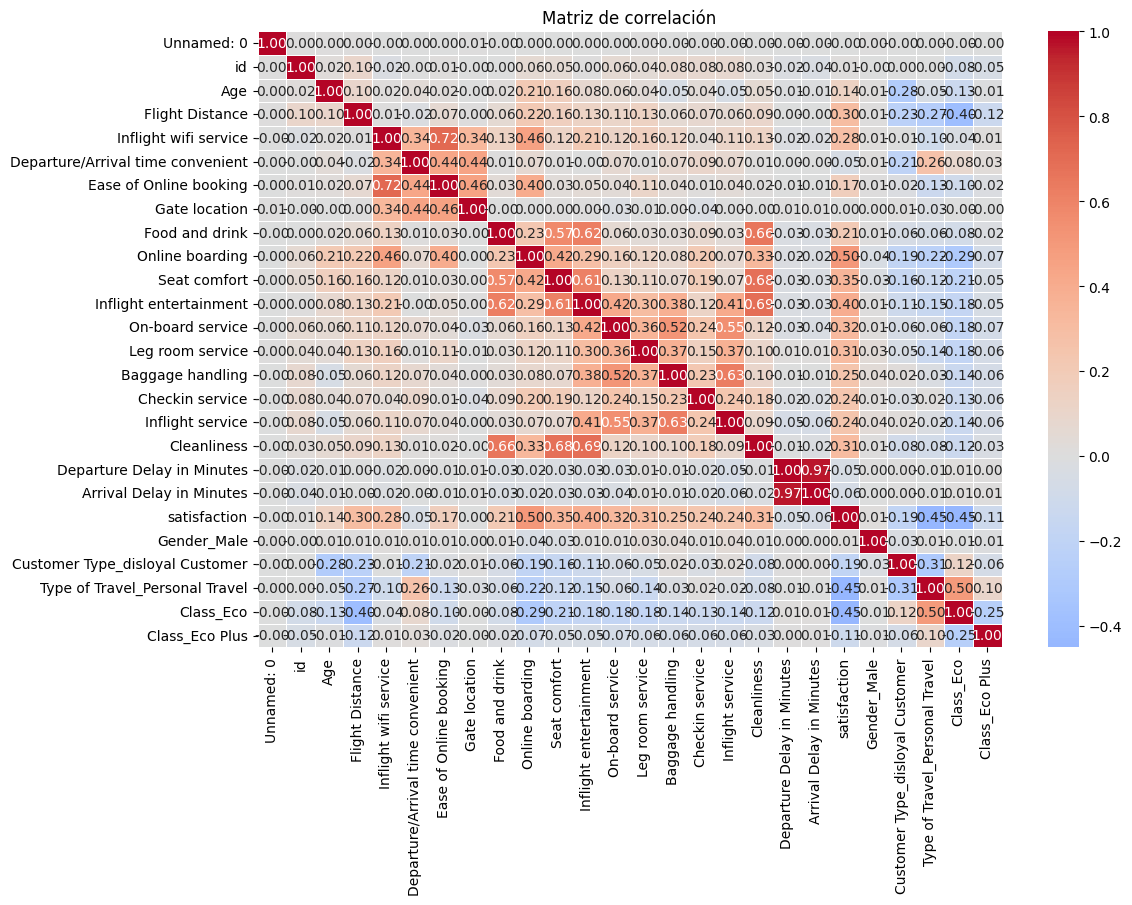

In [8]:
corr = df.corr(numeric_only=True)

plt.figure(figsize=(12, 8))
sns.heatmap(
    corr,
    cmap="coolwarm",
    center=0,
    annot=True,       
    fmt=".2f",         
    linewidths=0.5     
)
plt.title("Matriz de correlación")
plt.show()

Les variables relacionades amb l’experiència a bord, com `Seat comfort`,
`Inflight entertainment` i `On-board service`, mostren una correlació positiva
amb la satisfacció del passatger. En canvi, variables demogràfiques o relacionades
amb retards presenten una correlació més baixa.

Per aquest motiu, s’estableix un llindar de correlació absoluta de 0.3 i s’eliminen
aquelles variables amb una correlació feble o negativa amb la variable objectiu,
amb l’objectiu de reduir la dimensionalitat del conjunt de dades.

### 5.2 Clustering (K-Means)

L’algorisme K-Means permet identificar tres clústers diferenciats segons la percepció
del servei a bord.

In [9]:
service_features = [
    "Seat comfort",
    "Inflight entertainment",
    "On-board service",
    "Cleanliness",
    "Online boarding"
]

service_info = df[service_features].copy()

Triam aquestes variables ja que medeixen l'experiència subjectiva del passatger i volem agrupar en funció de la qualitat del servei, no per qui són ni la qualitat del vol.

In [10]:
df = pd.get_dummies(df, drop_first=True)

corr = df.corr(numeric_only=True)

llindar = 0.3
discorded_features = corr.columns[
    (corr["satisfaction"].abs() < llindar) &
    (corr.columns != "satisfaction")
].tolist()

df = df.drop(columns=discorded_features)

numeric_features = df.select_dtypes(include=np.number).drop(columns=["satisfaction"])

scaler = StandardScaler()
X_scaled = scaler.fit_transform(numeric_features)

kmeans = KMeans(n_clusters=3, random_state=42)
df["cluster"] = kmeans.fit_predict(X_scaled)


In [11]:
for col in service_features:
    df[col] = service_info[col].values

In [12]:
df.groupby("cluster")[service_features].mean()


,Seat comfort,Inflight entertainment,On-board service,Cleanliness,Online boarding
cluster,,,,,
0,3.504458,3.969618,3.566606,3.682637,1.999134
1,4.356377,4.214722,3.856694,4.110020,4.352281
2,2.282566,1.926521,2.688258,2.031353,2.705642


Un dels grups presenta valoracions elevades en totes les variables
analitzades, indicant un perfil de passatgers clarament satisfets. Un segon clúster
mostra valoracions intermèdies, mentre que el tercer agrupa passatgers amb puntuacions
baixes en comoditat, entreteniment i qualitat del servei.

Aquests resultats suggereixen l’existència de perfils diferenciats d’experiència del
passatger, fet que valida l’ús del clustering com a eina exploratòria.

In [13]:
pca = PCA(n_components=2, random_state=42)
X_pca = pca.fit_transform(X_scaled)

In [14]:
df_pca = pd.DataFrame(
    X_pca,
    columns=["PC1", "PC2"]
)

df_pca["cluster"] = df["cluster"].values


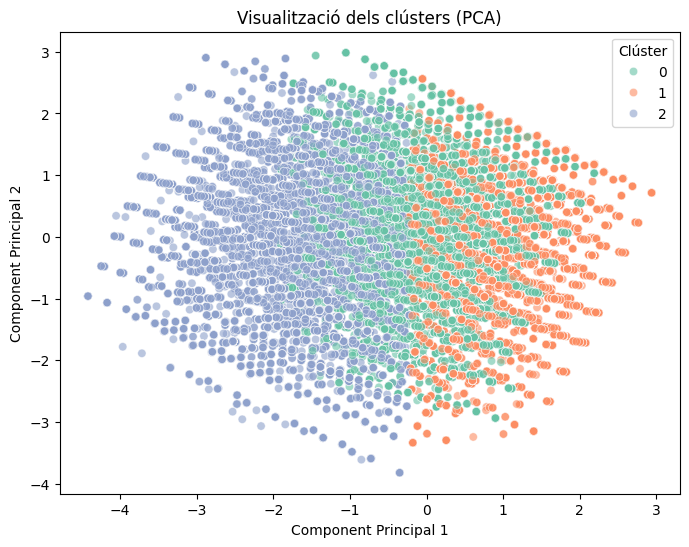

In [15]:
plt.figure(figsize=(8, 6))
sns.scatterplot(
    data=df_pca,
    x="PC1",
    y="PC2",
    hue="cluster",
    palette="Set2",
    alpha=0.6
)

plt.title("Visualització dels clústers (PCA)")
plt.xlabel("Component Principal 1")
plt.ylabel("Component Principal 2")
plt.legend(title="Clúster")
plt.show()


Per facilitar la visualització dels clústers obtinguts amb K-Means, s’ha aplicat una
reducció de dimensionalitat mitjançant PCA, projectant les dades en dues components
principals. Aquesta representació permet observar una separació raonable entre els
grups, especialment al llarg de la primera component principal.

Tot i que existeix cert solapament entre clústers, aquest comportament és esperable
en conjunts de dades reals d’alta dimensionalitat i indica que el clustering ha
capturat patrons diferenciats però no completament separables.

## 6. Prepocessament i partició

#### 6.1 Separació de variables

In [16]:
X = df.drop(columns=["satisfaction"])
y = df["satisfaction"]

En aquest pas es separen les variables explicatives (`X`) de la variable objectiu
(`y`). Les variables explicatives contenen tota la informació utilitzada pels
models per realitzar les prediccions, mentre que la variable objectiu representa
la satisfacció del passatger que es vol predir.

Aquesta separació és necessària per evitar que la informació de la variable
objectiu influeixi en el preprocessament o l’entrenament dels models, i permet
aplicar correctament les tècniques d’aprenentatge supervisat.

### 6.2 Preprocessador comú

In [17]:
num_features = X.columns

preprocessor = ColumnTransformer(
    transformers=[
        ("num", StandardScaler(), num_features)
    ]
)

Atès que les variables categòriques ja han estat transformades prèviament a format
numèric mitjançant One-Hot Encoding durant l’anàlisi exploratòria, el preprocessament
dels models es limita a l’escalat de les variables numèriques.

L’escalat mitjançant `StandardScaler` permet que totes les variables tinguin una
escala comparable, fet especialment rellevant per a models sensibles a la magnitud
de les dades, com els models lineals o les màquines de vectors de suport. Aquest
preprocessament s’integra dins d’un `Pipeline` per garantir una aplicació coherent
durant l’entrenament i la validació.

### 6.3 Divisió del conjunt de dades

In [18]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)


El conjunt de dades es divideix en dos subconjunts: un conjunt d’entrenament, utilitzat
per ajustar els models, i un conjunt de test, reservat exclusivament per avaluar el
seu rendiment final. S’utilitza una proporció del 80% per a l’entrenament i del 20%
per al test, una distribució habitual que permet disposar de prou dades per aprendre
sense comprometre l’avaluació.

La divisió es realitza tenint en compte la variable objectiu (`y`) per assegurar que
tant el conjunt d’entrenament com el de test continguin una proporció similar de
passatgers satisfets i insatisfets. D’aquesta manera, l’avaluació dels models es fa
sobre dades representatives del conjunt original. El paràmetre `random_state`
s’utilitza per garantir que els resultats obtinguts siguin reproduïbles.


## 7. Mètrica d'avaluació: F1-Score

Per a l’avaluació dels models s’ha utilitzat el F1-score en lloc de l’`accuracy`.
Aquesta decisió es deu al fet que el conjunt de dades presenta un cert
desbalanceig entre classes, i que classificar erròniament un passatger insatisfet
com a satisfet (fals negatiu) té un cost més elevat que l’error contrari.

El F1-score combina la precisió i el recall en una única mètrica, proporcionant
una avaluació més equilibrada del rendiment del model quan les classes no estan
perfectament balancejades.

### 7.1 F-β score

De manera general, el F1-score és un cas particular del F-β score, definit com:

Fβ = (1 + β²) · (precision · recall) / (β² · precision + recall)

El paràmetre β controla la importància relativa del recall respecte a la precisió:
valors de β superiors a 1 donen més pes al recall, mentre que valors inferiors a 1
prioritzen la precisió.

En aquesta pràctica s’utilitza el F1-score, que correspon al cas β = 1, on la
precisió i el recall tenen la mateixa importància.


## 8. Models i GridSearch

In [19]:
models = {
    "Perceptron": (
        Perceptron(),
        {
            "model__alpha": [0.0001, 0.001, 0.01],
            "model__max_iter": [500, 1000, 2000]
        }
    ),
    "Logistic Regression": (
        LogisticRegression(),
        {
            "model__C": [0.01, 0.1, 1],
            "model__solver": ["lbfgs", "liblinear", "saga"]
        }
    ),
    "SVM Lineal": (
        LinearSVC(),
        {
            "model__C": [0.01, 0.1, 1],
            "model__max_iter": [2000, 5000, 10000]
        }
    ),
    "Decision Tree": (
        DecisionTreeClassifier(),
        {
            "model__max_depth": [5, 10, 20, None],
            "model__min_samples_split": [2, 10, 50],
            "model__min_samples_leaf": [1, 5, 20]

        }
    ),
    "Random Forest": (
        RandomForestClassifier(),
        {
            "model__criterion": ["gini", "entropy"],
            "model__n_estimators": [100, 200],
            "model__max_depth": [None, 20],
            "model__min_samples_split": [2, 10]
        }
    )
}

En aquest apartat es comparen diversos models d’aprenentatge automàtic amb l’objectiu
d’analitzar el seu comportament sobre el conjunt de dades. S’han seleccionat models
de naturalesa diversa, incloent models lineals, models basats en marges i models
basats en arbres, per obtenir una comparació representativa.

Per a cada model es defineix un conjunt d’hiperparàmetres que s’ajusten mitjançant
`GridSearchCV`. La cerca es realitza combinant com a mínim dos hiperparàmetres amb
diversos valors possibles, permetent analitzar l’impacte de cada paràmetre en el
rendiment del model.

- **Perceptró**: model lineal simple que serveix com a punt de referència.
- **Regressió Logística**: model lineal probabilístic àmpliament utilitzat en
  classificació binària.
- **SVM Lineal**: model basat en marges, adequat per conjunts de dades d’alta
  dimensionalitat.
- **Decision Tree**: model no lineal i interpretable, capaç de capturar relacions
  complexes.
- **Random Forest**: conjunt d’arbres que millora la generalització i redueix la
  variància dels arbres individuals.

Els rangs d’hiperparàmetres s’han escollit per controlar explícitament la
regularització, la convergència i la complexitat dels models, evitant cerques
excessivament grans i prioritzant la interpretabilitat i l’eficiència computacional.

> **Nota important sobre l’ús de SVM**
>
> **Cal destacar que s’ha optat per utilitzar una SVM lineal en lloc d’una SVM amb
> nuclis no lineals (com el nucli RBF).** Aquesta decisió es deu principalment al cost
> computacional elevat de les SVM no lineals, especialment en conjunts de dades amb
> un nombre elevat de mostres i característiques, fet que incrementa considerablement
> el temps d’entrenament i de cerca d’hiperparàmetres.
>
> Atès que l’objectiu principal de la pràctica és la comparació de models i no
> l’optimització exhaustiva d’un únic algorisme, s’ha prioritzat una solució més
> eficient computacionalment que permeti obtenir resultats comparables en un temps
> raonable.


## 9. Entrenament i avaluació conjunta

En aquest apartat s’entrenen i s’avaluen de manera sistemàtica tots els models
seleccionats.

In [20]:
results = {}

for name, (model, params) in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    grid = GridSearchCV(
        pipe,
        param_grid=params,
        scoring="f1",
        cv=5,
        n_jobs=-1
    )
    
    grid.fit(X_train, y_train)
    
    y_pred = grid.predict(X_test)
    
    results[name] = {
        "best_params": grid.best_params_,
        "f1": f1_score(y_test, y_pred),
        "y_pred": y_pred
    }

### Consideració sobre el cost computacional

Durant el disseny de la pràctica es va considerar la possibilitat de realitzar la cerca
d’hiperparàmetres sobre un subconjunt del conjunt d’entrenament, amb l’objectiu de
reduir el temps d’execució del GridSearchCV. Aquesta estratègia és habitual en conjunts
de dades grans, ja que permet obtenir una bona estimació dels hiperparàmetres òptims
amb un cost computacional menor.

Aquesta aproximació és especialment útil en models amb un cost d’entrenament elevat,
com les `SVM` i els `Random Forest`, on el nombre de combinacions d’hiperparàmetres i
la validació creuada poden incrementar significativament el temps de càlcul.

Finalment, s’ha optat per utilitzar tot el conjunt d’entrenament per assegurar una
avaluació més robusta dels models, acceptant un major temps de càlcul.

## 10. Comparació de resultats

### 10.1 Resum models

In [21]:
results_df = pd.DataFrame({
    model: {
        "F1-score": results[model]["f1"]
    }
    for model in results
}).T

results_df.sort_values("F1-score", ascending=False)

,F1-score
Random Forest,0.891244
Decision Tree,0.887765
Logistic Regression,0.822843
SVM Lineal,0.821555
Perceptron,0.773137


La taula resumeix el rendiment dels diferents models utilitzant el F1-score com a
mètrica d’avaluació. S’observa que els models basats en arbres presenten els millors
resultats, destacant especialment el Random Forest, que obté el F1-score més elevat.

El Decision Tree mostra també un rendiment molt competitiu, tot i ser un model
més simple. En canvi, els models lineals (Regressió Logística, SVM lineal i
Perceptró) obtenen valors inferiors, indicant una menor capacitat per capturar
relacions complexes presents en el conjunt de dades.

Aquests resultats suggereixen que les relacions entre les variables i la
satisfacció del passatger no són estrictament lineals, fet que afavoreix l’ús de
models no lineals com els basats en arbres.

### 10.2 Millora d'hiperparàmetres

In [22]:
for model, res in results.items():
    print(f"\n{model}")
    print("Best params:", res["best_params"])


Perceptron
Best params: {'model__alpha': 0.0001, 'model__max_iter': 500}

Logistic Regression
Best params: {'model__C': 0.01, 'model__solver': 'liblinear'}

SVM Lineal
Best params: {'model__C': 0.1, 'model__max_iter': 2000}

Decision Tree
Best params: {'model__max_depth': 20, 'model__min_samples_leaf': 1, 'model__min_samples_split': 50}

Random Forest
Best params: {'model__criterion': 'gini', 'model__max_depth': 20, 'model__min_samples_split': 10, 'model__n_estimators': 100}


Els resultats del GridSearch mostren que cada model presenta una configuració òptima
d’hiperparàmetres diferent, adaptada a la seva naturalesa i al conjunt de dades.

En el cas del **Perceptró**, es selecciona un valor baix del paràmetre `alpha`,
indicant una regularització suau i un model relativament simple. La **Regressió
Logística** opta també per un valor petit de `C`, fet que reforça la regularització
i millora la capacitat de generalització.

Per a la **SVM lineal**, el valor intermedi de `C` reflecteix un equilibri entre
marge i error de classificació, mentre que el nombre d’iteracions assegura la
convergència del model.

Pel que fa als models basats en arbres, tant l’**Decision Tree** com el
**Random Forest** seleccionen profunditats relativament elevades i valors de
separació més restrictius, permetent capturar relacions no lineals sense un
creixement excessiu de la complexitat. En el cas del Bosc Aleatori, l’ús de més
arbres (`n_estimators`) i del criteri `entropy` contribueix a millorar la
generalització del model.

### 10.3 Matrius de confusió
Les matrius de confusió permeten analitzar amb més detall el comportament de cada
model, mostrant la distribució d’encerts i errors en la classificació de passatgers
satisfets i insatisfets.


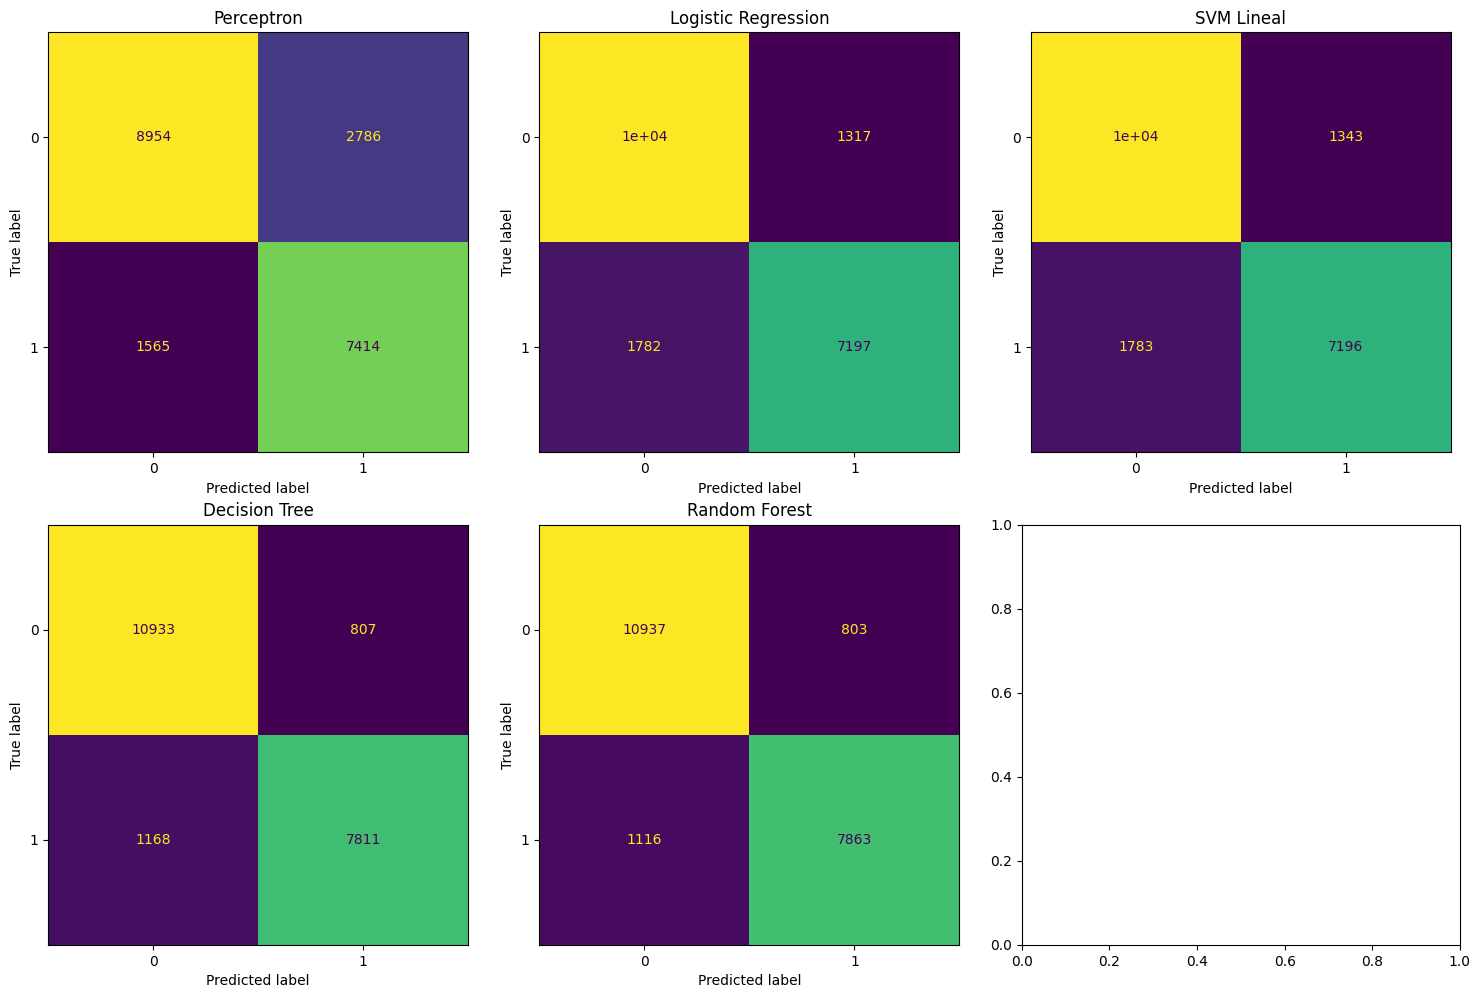

In [23]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (name, res) in zip(axes, results.items()):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        res["y_pred"],
        ax=ax,
        colorbar=False
    )
    ax.set_title(name)

plt.tight_layout()
plt.show()

Els models basats en arbres, especialment el **Random Forest**, presenten el millor
equilibri entre veritables positius i veritables negatius, amb un nombre reduït tant
de falsos positius com de falsos negatius. Aquest fet explica el seu F1-score més
elevat i confirma la seva millor capacitat de generalització.

El **Decision Tree** mostra un comportament similar, tot i que amb lleugerament més
errors, mentre que els models lineals (**Regressió Logística** i **SVM lineal**)
presenten un major nombre de falsos negatius, indicant una menor sensibilitat a la
detecció de passatgers satisfets.

Finalment, el **Perceptró** és el model amb més errors globals, especialment en la
classificació incorrecta de passatgers satisfets com a insatisfets, fet que justifica
el seu rendiment inferior segons la mètrica F1-score.

## 11. Discusió crítica de resultats

Els resultats obtinguts mostren diferències clares entre els models analitzats, tant
en termes de rendiment com de comportament davant els errors de classificació. Els
models basats en arbres, especialment el Random Forest, ofereixen els millors
resultats segons el F1-score, fet que indica una major capacitat per capturar
relacions no lineals presents en el conjunt de dades.

En particular, el Random Forest destaca per reduir el nombre de falsos negatius,
un tipus d’error especialment rellevant en aquest problema, ja que implica
classificar un passatger insatisfet com a satisfet. Aquest comportament explica el
seu millor rendiment global respecte a la resta de models.

Els models lineals, com la Regressió Logística i la SVM lineal, presenten un
rendiment lleugerament inferior, atribuïble a les seves limitacions a l’hora de
modelar interaccions complexes entre variables. Tot i això, aquests models
ofereixen avantatges en termes de simplicitat, interpretabilitat i eficiència
computacional.

El Perceptró obté els pitjors resultats, fet esperable atesa la seva simplicitat i
la seva dependència d’una separabilitat estrictament lineal de les dades, la qual
no es compleix en aquest conjunt de dades.

## 12. Conclusions

L’ús del F1-score ha estat clau per avaluar correctament el rendiment dels models en
un problema amb classes no perfectament equilibrades, permetent una valoració més
realista de la capacitat de predicció de la satisfacció dels passatgers.

La comparació conjunta de diversos models i configuracions d’hiperparàmetres ha
facilitat una avaluació objectiva i honesta del seu comportament, posant de manifest
les fortaleses i limitacions de cada aproximació.

Finalment, el desenvolupament de tot el procés ha estat més rellevant que l’obtenció d’una mètrica
concreta, complint així l’objectiu principal de la pràctica d’aplicar i justificar
les tècniques d’aprenentatge automàtic.

## 13. Avaluació final amb conjunt de test extern

Un cop seleccionats els millors hiperparàmetres mitjançant validació creuada sobre el
conjunt d’entrenament, els models s’avaluen utilitzant un conjunt de test extern
(`test.csv`) que no ha intervingut en cap fase del procés d’ajust. Aquest procediment
permet estimar de manera més realista la capacitat de generalització de cada model.

El conjunt de test extern se sotmet al mateix procés de neteja i transformació que el
conjunt d’entrenament, incloent l’eliminació de valors nuls, la conversió de la
variable objectiu a format binari i l’aplicació de One-Hot Encoding. A més, es garanteix
que ambdós conjunts comparteixin exactament la mateixa estructura de variables,
afegint o eliminant columnes quan és necessari.


### 13.1 Avaluació dels models sobre dades no vistes

In [24]:
df_test = pd.read_csv("test.csv")

df_test = df_test.dropna()

df_test["satisfaction"] = df_test["satisfaction"].map({
    "satisfied": 1,
    "neutral or dissatisfied": 0
})

df_test = pd.get_dummies(df_test, drop_first=True)

df_test = df_test.reindex(columns=df.columns, fill_value=0)


In [25]:
X_test_ext = df_test.drop(columns=["satisfaction"])
y_test_ext = df_test["satisfaction"]

final_test_results = {}

for name, (model, _) in models.items():
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    
    best_params = results[name]["best_params"]
    pipe.set_params(**best_params)
    
    X_train_full = df.drop(columns=["satisfaction"])
    y_train_full = df["satisfaction"]
    
    pipe.fit(X_train_full, y_train_full)
    y_pred_ext = pipe.predict(X_test_ext)
    
    final_test_results[name] = {
        "F1-score (test extern)": f1_score(y_test_ext, y_pred_ext)
    }

pd.DataFrame(final_test_results).T.sort_values("F1-score (test extern)", ascending=False)


,F1-score (test extern)
Decision Tree,0.878070
Random Forest,0.869671
Logistic Regression,0.825150
SVM Lineal,0.823550
Perceptron,0.751614


Per a cada model, s’utilitzen els millors hiperparàmetres obtinguts durant el
GridSearch i s’entrena el model utilitzant tot el conjunt d’entrenament disponible.
A continuació, es generen prediccions sobre el conjunt de test extern i es calcula
el F1-score com a mètrica d’avaluació.

Els resultats mostren que els models mantenen un rendiment similar al del conjunt
de test intern, destacant novament els models basats en arbres. El Decision Tree  i
el Random Forest obtenen els millors F1-score, indicant una bona capacitat de
generalització. Els models lineals presenten un rendiment estable però inferior,
mentre que el Perceptró torna a mostrar les limitacions observades anteriorment.

### 13.2 Matrius de confusió

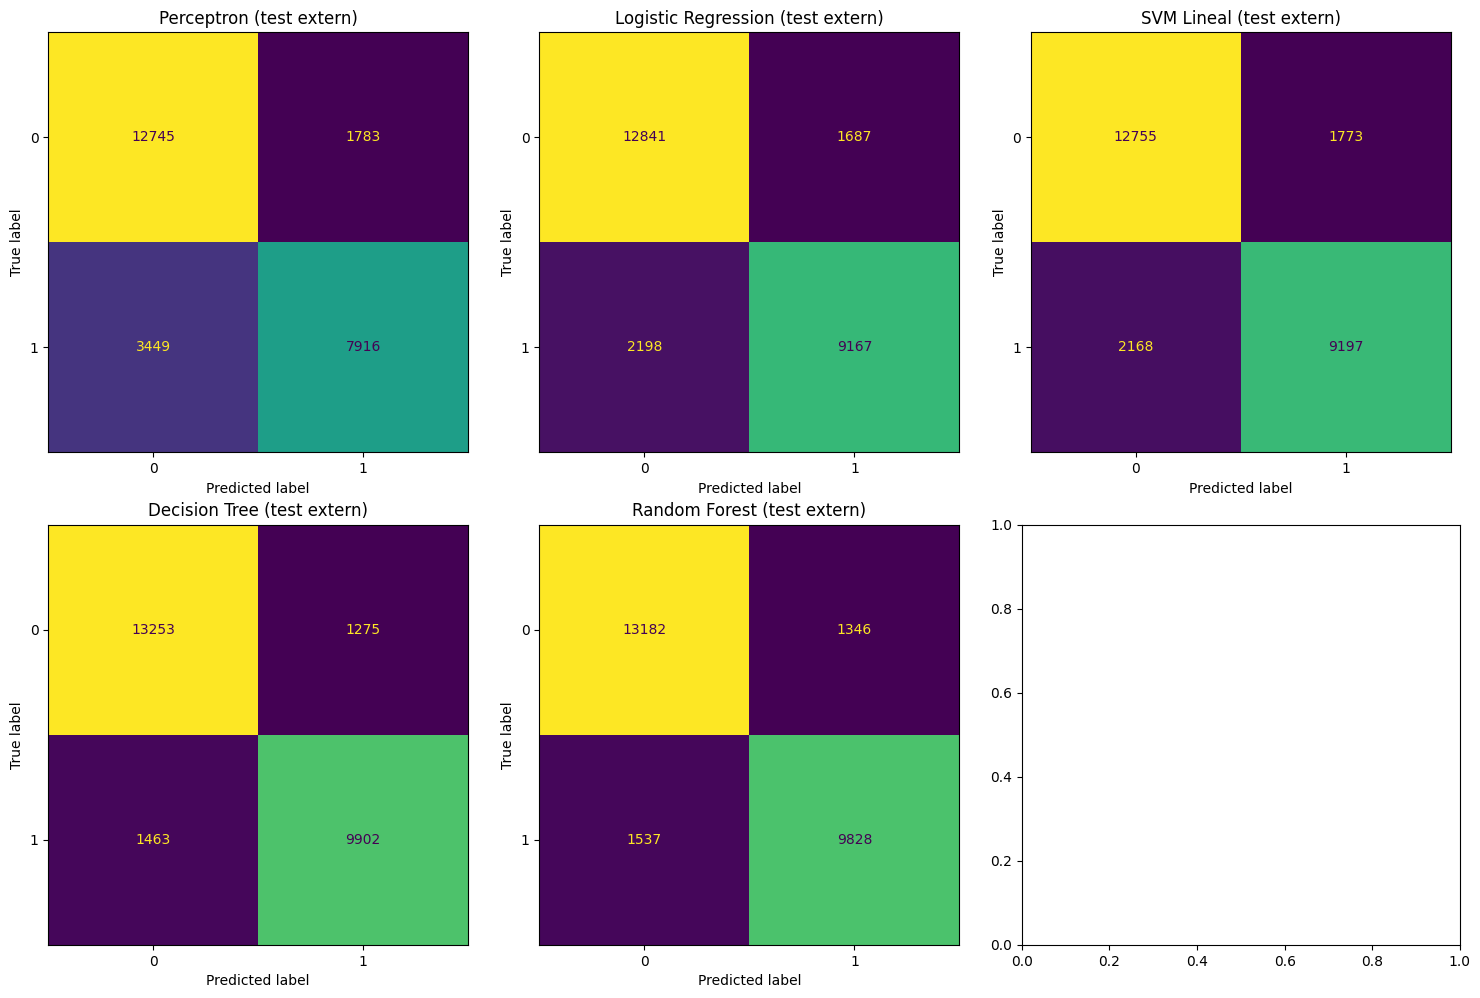

In [26]:
fig, axes = plt.subplots(2, 3, figsize=(15, 10))
axes = axes.flatten()

for ax, (name, (model, _)) in zip(axes, models.items()):
    pipe = Pipeline([
        ("preprocess", preprocessor),
        ("model", model)
    ])
    pipe.set_params(**results[name]["best_params"])
    
    X_train_full = df.drop(columns=["satisfaction"])
    y_train_full = df["satisfaction"]
    
    pipe.fit(X_train_full, y_train_full)
    y_pred_ext = pipe.predict(X_test_ext)
    
    ConfusionMatrixDisplay.from_predictions(y_test_ext, y_pred_ext, ax=ax, colorbar=False)
    ax.set_title(f"{name} (test extern)")

plt.tight_layout()
plt.show()


## 14. Conclusions finals 
A partir del conjunt de dades proporcionat, s’ha dut a terme una anàlisi completa de
la satisfacció dels passatgers d’una aerolínia, seguint totes les fases plantejades
a l’enunciat de la pràctica. El treball ha inclòs l’anàlisi exploratòria de dades, el
preprocessament, la comparació de diversos models de classificació i l’ajust dels
seus hiperparàmetres, sempre amb una justificació raonada de les decisions preses.

La comparació dels models ha permès observar diferències clares en el seu
comportament, destacant els models basats en arbres com els més adequats per a
aquest problema, especialment pel seu millor rendiment segons la mètrica F1-score
i la seva capacitat per reduir errors rellevants. Els models lineals, tot i ser més
simples i eficients computacionalment, han mostrat limitacions davant relacions més
complexes entre les variables.

L’avaluació final sobre un conjunt de test extern ha confirmat que els resultats
obtinguts no depenen exclusivament del conjunt de dades inicial, sinó que els models
mantenen un rendiment coherent sobre dades no vistes, indicant una bona capacitat de
generalització.

En conjunt, la pràctica compleix l’objectiu principal plantejat a l’enunciat: no
només comparar el rendiment tècnic de diferents models, sinó també fomentar una
anàlisi crítica del procés seguit i entendre com i per què aquests models funcionen
en el context del problema analitzat.